# Resampling of IOBP2

In [1]:
import os
import numpy as np
import pandas as pd
from datetime import datetime

### Read Existing Tables

In [3]:
file_path = "../../data/out/IOBP2 RCT Public Dataset/"
file_map = {
    'cgm': 'IOBP2_cgm_history.csv.gz',
    'bolus': 'IOBP2_bolus_event_history.csv.gz',
    'basal': 'IOBP2_basal_event_history.csv.gz',
}

In [4]:
def get_df_from_file(file_path, file_name, parse_datetime=True, sep=','):
    df = pd.read_csv(file_path + file_name, sep=sep)
    if parse_datetime:
        df['date'] = pd.to_datetime(df['datetime'], unit='s')
    return df

In [5]:
def get_extended_df(original_df, value_column):
    """
    Get a df where quantities are distributed throughout 5-minute intervals instead of having start- and end dates.
    """
    new_rows = []
    for _, row in original_df.iterrows():
        new_rows.extend(split_duration(row, value_column))
    extended_df = pd.DataFrame(new_rows)
    extended_df.set_index('date', inplace=True)
    return extended_df

def split_duration(row, value_column):
    """
    For features with a duration, we split the values across 5-minute intervals by adding
    new rows for every 5-minute window in duration, and equally split the original quantity across those rows.
    """
    duration = row['end_date'] - row['date']
    rounded_duration = round(duration / pd.Timedelta(minutes=5)) * pd.Timedelta(minutes=5)
    num_intervals = rounded_duration // pd.Timedelta(minutes=5)
    if num_intervals < 1:
        num_intervals = 1
    value_per_interval = row[value_column] / num_intervals
    new_rows = []
    for i in range(int(num_intervals)):
        new_row = {
            'date': row['date'] + pd.Timedelta(minutes=5 * i),
            value_column: value_per_interval,
            'patient_id': row['patient_id'],
        }
        new_rows.append(new_row)
    return new_rows

In [37]:
def parse_flair_dates(dates, format_date = '%m/%d/%Y', format_time = '%I:%M:%S %p'):
    """Parse date strings separately for those with/without time component, interpret those without as midnight (00AM)
    Args:
        dates (pd.DataFrame): datetimes (string) either in in the %m/%d/%Y or %m/%d/%Y %I:%M:%S %p format
    Returns:
        pandas series: with parsed dates
    """
    #make sure to only parse dates if the value is not null
    dates = dates.astype(str)
    only_date = dates.apply(len) <=10
    dates_copy = dates.copy()
    dates_copy.loc[only_date] = pd.to_datetime(dates.loc[only_date], format=format_date)
    dates_copy.loc[~only_date] = pd.to_datetime(dates.loc[~only_date], format=f'{format_date} {format_time}')
    return dates_copy.astype('datetime64[ns]')

In [7]:
df_glucose = get_df_from_file(file_path, file_map['cgm'])
df_bolus = get_df_from_file(file_path, file_map['bolus'])
df_basal = get_df_from_file(file_path, file_map['basal'])


### Resample Existing Tables

In [8]:
df_glucose.set_index('date', inplace=True)
df_glucose.head()

,patient_id,datetime,cgm
date,,,
2020-08-14 00:01:23,183,1597363283,91
2020-08-14 00:06:23,183,1597363583,102
2020-08-14 00:11:23,183,1597363883,105
2020-08-14 00:16:23,183,1597364183,103
2020-08-14 00:21:23,183,1597364483,98


In [9]:
df_bolus_orig = df_bolus.copy()
df_bolus['end_date'] = df_bolus['date'] + pd.to_timedelta(df_bolus['delivery_duration'], unit='s')
df_bolus = get_extended_df(df_bolus, 'bolus')
df_bolus

,bolus,patient_id
date,,
2020-08-13 23:56:23,0.000,183
2020-08-14 00:01:23,0.000,183
2020-08-14 00:06:23,0.000,183
2020-08-14 00:11:23,0.000,183
2020-08-14 00:16:23,0.000,183
...,...,...
2021-01-28 15:04:27,0.097,432
2021-01-28 15:09:27,0.102,432
2021-01-28 15:14:27,0.107,432


In [10]:
print(f'New sum after distribution of extended boluses: {df_bolus["bolus"].sum():.2f}, should be: {df_bolus_orig["bolus"].sum():.2f}')

New sum after distribution of extended boluses: 1701765.25, should be: 1701765.25


In [11]:
df_basal_orig = df_basal.copy()
df_basal.sort_values(by=['patient_id', 'date'], inplace=True)
df_basal.set_index('date', inplace=True)
df_basal

,patient_id,datetime,basal_rate
date,,,


In [12]:
processed_dfs = []
subject_ids = df_glucose['patient_id'].unique()
print("Subjects:", len(subject_ids))
for subject_id in subject_ids:
    df_subject = df_glucose[df_glucose['patient_id'] == subject_id].copy()
    df_subject = df_subject[['cgm']].resample('5min', label='right').mean()
    df_subject['patient_id'] = subject_id
    df_subject.sort_index(inplace=True)

    def merge_data(df_col, df_subject, col_names, subject_id, agg_type='sum'):
        """ agg_type is data aggregation type. """
        df_subset = df_col[df_col['patient_id'] == subject_id].copy()
        if not df_subset.empty:
            if agg_type == 'mean':
                df_subset = df_subset[df_subset[col_names].notna()][col_names].resample('5min', label='right').mean()
            elif agg_type == 'sum':
                df_subset = df_subset[df_subset[col_names].notna()][col_names].resample('5min', label='right').sum()
            elif agg_type == 'first':
                df_subset = df_subset[df_subset[col_names].notna()][col_names].resample('5min', label='right').first()
            elif agg_type == 'last':
                df_subset = df_subset[df_subset[col_names].notna()][col_names].resample('5min', label='right').last()
            else:
                df_subset = df_subset[df_subset[col_names].notna()][col_names].resample('5min', label='right').sum()
            df_subject = pd.merge(df_subject, df_subset, on="date", how='outer')
        else:
            df_subject[col_names] = np.nan
        return df_subject

    # Add insulin and insulin type
    df_subject = merge_data(df_bolus, df_subject, ['bolus'], subject_id, agg_type='sum')
    df_subject = merge_data(df_basal, df_subject, ['basal_rate'], subject_id, agg_type='last')
    df_subject['basal_rate'] = df_subject['basal_rate'].ffill()
    
    df_subject['patient_id'] = subject_id
    df_subject = df_subject.rename(columns={'patient_id': 'id', 'basal_rate': 'basal', 'cgm': 'CGM'})
    processed_dfs.append(df_subject)
    print(f"{subject_id} is finished processing")

df_final = pd.concat(processed_dfs)

Subjects: 343
183 is finished processing
413 is finished processing
347 is finished processing
480 is finished processing
107 is finished processing
394 is finished processing
252 is finished processing
71 is finished processing
440 is finished processing
235 is finished processing
541 is finished processing
362 is finished processing
554 is finished processing
395 is finished processing
167 is finished processing
76 is finished processing
10 is finished processing
511 is finished processing
459 is finished processing
259 is finished processing
181 is finished processing
46 is finished processing
577 is finished processing
590 is finished processing
223 is finished processing
233 is finished processing
443 is finished processing
146 is finished processing
59 is finished processing
393 is finished processing
171 is finished processing
217 is finished processing
226 is finished processing
462 is finished processing
23 is finished processing
254 is finished processing
529 is finished proc

In [13]:
df_final

,CGM,id,bolus,basal
date,,,,
2020-08-14 00:00:00,NaN,183,0.000,NaN
2020-08-14 00:05:00,91.0,183,0.000,NaN
2020-08-14 00:10:00,102.0,183,0.000,NaN
2020-08-14 00:15:00,105.0,183,0.000,NaN
2020-08-14 00:20:00,103.0,183,0.000,NaN
...,...,...,...,...
2020-10-13 14:30:00,NaN,195,0.142,NaN
2020-10-13 14:35:00,NaN,195,0.147,NaN
2020-10-13 14:40:00,NaN,195,0.137,NaN


### Add Additional Tables

We found:
- Meals and meal sizes as string
- Insulin type
- Age
- Weight
- Height
- Gender

In [14]:
raw_data_file_path = "../../data/raw/IOBP2 RCT Public Dataset/Data Tables/"

In [34]:
# Adding meals
df_meals = get_df_from_file(raw_data_file_path, 'IOBP2MealDose.txt', parse_datetime=False, sep='|')
print(df_meals['MealDoseType'].unique())
print(df_meals['MealDoseAnnounceTm'].unique())
print(df_meals['MealDoseAnnounceAmt'].unique())
def get_datetime_from_separate_cols(df, date_col, hour_col, min_col, ampm_col):
    date_str = df[date_col]
    hour_str = df[hour_col].astype(int).astype(str)
    min_str = df[min_col].astype(int).astype(str).str.zfill(2)
    datetime_str = date_str + ' ' + hour_str + ':' + min_str + ' ' + df[ampm_col]
    return pd.to_datetime(datetime_str, format='%m/%d/%Y %I:%M %p')

def get_meal_label(row):
    labels = []
    if row['MealDoseAnnounceAmt'] == 'Usual':
        labels.append('Medium')
    elif row['MealDoseAnnounceAmt'] == 'Less than usual':
        labels.append('Small')
    elif row['MealDoseAnnounceAmt'] == 'More than usual':
        labels.append('Large')
    if row['MealDoseType'] == 'Snack':
        labels.append('Snack')
    elif row['MealDoseAnnounceTm'] in ['Lunch', 'Dinner', 'Breakfast']:
        labels.append(row['MealDoseAnnounceTm'])
    return ' '.join(labels) if labels else None

df_meals['date'] = get_datetime_from_separate_cols(df_meals, 'MealDoseDt', 'MealDoseHr', 'MealDoseMin', 'MealDoseAmPm')
df_meals['meal_label'] = df_meals.apply(get_meal_label, axis=1)
df_meals = df_meals[['PtID', 'date', 'meal_label']]
df_meals = df_meals[df_meals['meal_label'].notna()]
df_meals = df_meals.rename(columns={'PtID': 'id'})
df_meals

['Main meal' 'Snack' nan]
['Lunch' 'Dinner' 'Breakfast' 'Would not have announced' nan]
['Usual' 'More than usual' 'Less than usual' nan]


,id,date,meal_label
0,258,2020-11-16 12:20:00,Medium Lunch
1,258,2020-11-16 18:25:00,Medium Dinner
2,258,2020-11-17 06:20:00,Medium Breakfast
3,258,2020-11-17 11:25:00,Medium Lunch
4,258,2020-11-17 19:35:00,Medium Dinner
...,...,...,...
1153,597,2020-12-05 17:15:00,Large Dinner
1154,597,2021-01-05 13:22:00,Medium Lunch
1155,597,2021-01-06 18:00:00,Medium Dinner
1156,597,2021-01-07 17:00:00,Medium Dinner


In [35]:
# Add carbs to df final
processed_dfs = []
subject_ids = df_final['id'].unique()
print("Subjects:", len(subject_ids))
for subject_id in subject_ids:
    df_subject = df_final[df_final['id'] == subject_id].copy()
    df_subject.sort_index(inplace=True)

    # Add meals
    df_subject_meals = df_meals[df_meals['id'] == subject_id].copy()
    df_subject_meals.set_index('date', inplace=True)
    df_subject_meals = df_subject_meals[df_subject_meals['meal_label'].notna()]['meal_label'].resample('5min', label='right').last()
    df_subject = pd.merge(df_subject, df_subject_meals, on="date", how='outer')
    
    df_subject['id'] = subject_id
    processed_dfs.append(df_subject)
    print(f"{subject_id} is finished processing")

df_final = pd.concat(processed_dfs)
df_final

Subjects: 343
183 is finished processing
413 is finished processing
347 is finished processing
480 is finished processing
107 is finished processing
394 is finished processing
252 is finished processing
71 is finished processing
440 is finished processing
235 is finished processing
541 is finished processing
362 is finished processing
554 is finished processing
395 is finished processing
167 is finished processing
76 is finished processing
10 is finished processing
511 is finished processing
459 is finished processing
259 is finished processing
181 is finished processing
46 is finished processing
577 is finished processing
590 is finished processing
223 is finished processing
233 is finished processing
443 is finished processing
146 is finished processing
59 is finished processing
393 is finished processing
171 is finished processing
217 is finished processing
226 is finished processing
462 is finished processing
23 is finished processing
254 is finished processing
529 is finished proc

,CGM,id,bolus,basal,meal_label
date,,,,,
2020-08-14 00:00:00,NaN,183,0.0,NaN,NaN
2020-08-14 00:05:00,91.0,183,0.0,NaN,NaN
2020-08-14 00:10:00,102.0,183,0.0,NaN,NaN
2020-08-14 00:15:00,105.0,183,0.0,NaN,NaN
2020-08-14 00:20:00,103.0,183,0.0,NaN,NaN
...,...,...,...,...,...
2020-10-16 08:15:00,NaN,195,NaN,NaN,None
2020-10-16 08:20:00,NaN,195,NaN,NaN,None
2020-10-16 08:25:00,NaN,195,NaN,NaN,None


In [36]:
df_final[df_final['meal_label'].notna()]

,CGM,id,bolus,basal,meal_label
date,,,,,
2021-03-20 13:20:00,NaN,183,NaN,NaN,Large Lunch
2021-03-20 18:50:00,NaN,183,NaN,NaN,Medium Dinner
2021-03-21 07:05:00,NaN,183,NaN,NaN,Small Breakfast
2021-03-21 11:50:00,NaN,183,NaN,NaN,Large Lunch
2021-03-21 19:05:00,NaN,183,NaN,NaN,Medium Dinner
...,...,...,...,...,...
2020-10-13 20:05:00,NaN,195,NaN,NaN,Medium Dinner
2020-10-15 09:05:00,NaN,195,NaN,NaN,Snack
2020-10-15 11:35:00,NaN,195,NaN,NaN,Small Lunch


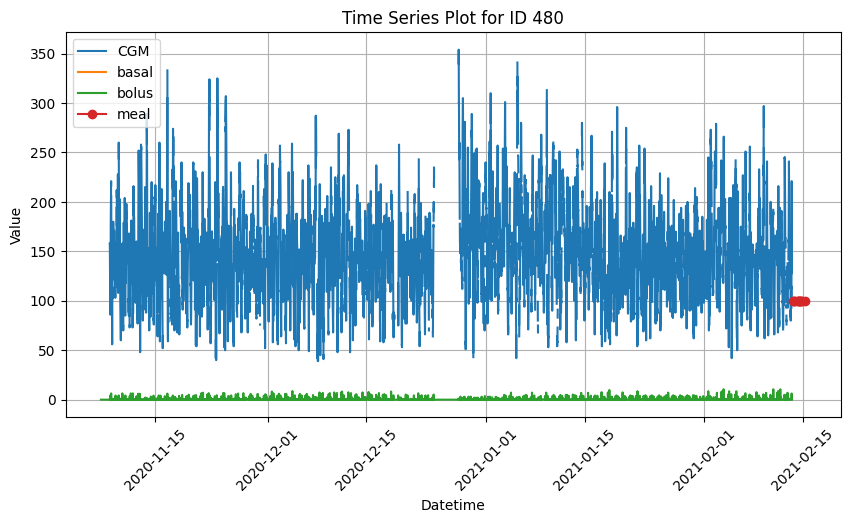

In [53]:
# Plot 
import pandas as pd
import matplotlib.pyplot as plt

subject_id = df_final['id'].unique()[3]

# Filter the data for that ID
df_filtered = df_final[df_final['id'] == subject_id].copy().tail(12*24*100)
df_filtered['meal'] = df_filtered['meal_label'].apply(lambda x: 100 if isinstance(x, str) else x)

# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(df_filtered.index, df_filtered['CGM'], linestyle='-', label=f'CGM')
plt.plot(df_filtered.index, df_filtered['basal'], linestyle='-', label=f'basal')
plt.plot(df_filtered.index, df_filtered['bolus'], linestyle='-', label=f'bolus')
plt.plot(df_filtered.index, df_filtered['meal'], marker='o', linestyle='-', label=f'meal')
plt.xlabel('Datetime')
plt.ylabel('Value')
plt.title(f'Time Series Plot for ID {subject_id}')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [54]:
# Why are all meals _after_ the study period...? 
df_filtered[df_filtered['meal'] > 0]

,CGM,id,bolus,basal,meal_label,meal
date,,,,,,
2021-02-13 13:15:00,NaN,480,NaN,NaN,Small Lunch,100.0
2021-02-13 17:10:00,NaN,480,NaN,NaN,Small Dinner,100.0
2021-02-13 21:15:00,NaN,480,NaN,NaN,Small Snack,100.0
2021-02-14 07:20:00,NaN,480,NaN,NaN,Small Breakfast,100.0
2021-02-14 08:50:00,NaN,480,NaN,NaN,Snack,100.0
2021-02-14 12:35:00,NaN,480,NaN,NaN,Snack,100.0
2021-02-14 13:40:00,NaN,480,NaN,NaN,Small Lunch,100.0
2021-02-14 14:55:00,NaN,480,NaN,NaN,Snack,100.0
2021-02-14 17:40:00,NaN,480,NaN,NaN,Medium Dinner,100.0


In [63]:
# Adding meals (WEIGHT IS ALSO HERE!)
df_meals_v2 = get_df_from_file(raw_data_file_path, 'IOBP2DeviceiLet.txt', parse_datetime=False, sep='|')
df_meals_v2

,RecID,PtID,PtWeight,UploadIndex,DeviceDtTm,CGMVal,BgCal,BGMVal,CalibrVal,SiteGbTb,...,InsComp,InsDelivPrev,BasalDelivPrev,BolusDelivPrev,MealTimeDose,MealTimeOfDay,MealSize,MealBolus,MealBolusDelivPrev,DlyOutput
0,1817,183,94.0,1816,8/14/2020 12:01:23 AM,91.0,-1.0,NaN,NaN,1.0,...,0.000,0.000,0.000,0.0,0.0,NaN,NaN,0.0,0.0,1.0
1,1818,183,94.0,1817,8/14/2020 12:06:23 AM,102.0,-1.0,NaN,NaN,1.0,...,0.000,0.000,0.000,0.0,0.0,NaN,NaN,0.0,0.0,1.0
2,1819,183,94.0,1818,8/14/2020 12:11:23 AM,105.0,-1.0,NaN,NaN,1.0,...,0.000,0.000,0.000,0.0,0.0,NaN,NaN,0.0,0.0,1.0
3,1820,183,94.0,1819,8/14/2020 12:16:23 AM,103.0,-1.0,NaN,NaN,1.0,...,0.000,0.000,0.000,0.0,0.0,NaN,NaN,0.0,0.0,1.0
4,1821,183,94.0,1820,8/14/2020 12:21:23 AM,98.0,-1.0,NaN,NaN,1.0,...,0.000,0.000,0.000,0.0,0.0,NaN,NaN,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8640844,8796785,432,81.0,19351,1/28/2021 3:09:27 PM,216.0,-1.0,NaN,NaN,1.0,...,0.100,0.097,0.097,0.0,0.0,NaN,NaN,0.0,0.0,1.0
8640845,8796786,432,81.0,19352,1/28/2021 3:14:27 PM,221.0,-1.0,NaN,NaN,1.0,...,0.105,0.102,0.102,0.0,0.0,NaN,NaN,0.0,0.0,1.0
8640846,8796787,432,81.0,19353,1/28/2021 3:19:27 PM,226.0,-1.0,NaN,NaN,1.0,...,0.105,0.107,0.107,0.0,0.0,NaN,NaN,0.0,0.0,1.0
8640847,8796788,432,81.0,19354,1/28/2021 3:24:27 PM,228.0,-1.0,NaN,NaN,1.0,...,0.115,0.107,0.107,0.0,0.0,NaN,NaN,0.0,0.0,1.0


In [64]:
# There are 50 times more meals in this table, and this is also the table used in the Cgm / basal / bolus script
print(df_meals_v2['MealSize'].unique())
print(df_meals_v2['MealTimeOfDay'].unique())
df_meals_v2[df_meals_v2['MealBolus'] > 0]

[nan 'Typical']
[nan 'Beginning' 'Middle' 'End']


,RecID,PtID,PtWeight,UploadIndex,DeviceDtTm,CGMVal,BgCal,BGMVal,CalibrVal,SiteGbTb,...,InsComp,InsDelivPrev,BasalDelivPrev,BolusDelivPrev,MealTimeDose,MealTimeOfDay,MealSize,MealBolus,MealBolusDelivPrev,DlyOutput
100,1917,183,94.0,1916,8/14/2020 8:20:27 AM,104.0,-1.0,NaN,NaN,1.0,...,4.065,0.043,0.043,0.000,11.0,Beginning,Typical,4.050,0.0,1.0
193,7637,413,68.0,1617,11/10/2019 6:17:56 AM,NaN,-1.0,NaN,NaN,1.0,...,2.165,0.056,0.056,0.000,11.0,Beginning,Typical,2.130,0.0,1.0
260,7704,413,68.0,1684,11/10/2019 11:52:43 AM,NaN,-1.0,NaN,NaN,1.0,...,2.595,0.000,0.000,0.000,21.0,Middle,Typical,2.550,0.0,1.0
383,9709,347,117.0,1981,10/16/2019 8:16:42 AM,132.0,-1.0,NaN,NaN,1.0,...,4.785,0.079,0.079,0.000,11.0,Beginning,Typical,4.705,0.0,1.0
514,11702,480,83.0,1972,8/23/2020 9:12:07 AM,181.0,-1.0,NaN,NaN,1.0,...,4.195,0.000,0.000,0.000,11.5,Beginning,NaN,4.145,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8640345,8796286,432,81.0,18852,1/26/2021 9:31:17 PM,NaN,-1.0,NaN,NaN,1.0,...,7.370,0.142,0.142,0.000,31.5,End,NaN,7.280,0.0,1.0
8640471,8796412,432,81.0,18978,1/27/2021 8:00:59 AM,NaN,-1.0,NaN,NaN,1.0,...,5.665,0.132,0.080,0.052,11.0,Beginning,Typical,5.575,0.0,1.0
8640544,8796485,432,81.0,19051,1/27/2021 2:05:30 PM,NaN,-1.0,NaN,NaN,1.0,...,6.330,0.335,0.130,0.205,21.0,Middle,Typical,6.255,0.0,1.0
8640632,8796573,432,81.0,19139,1/27/2021 9:25:14 PM,NaN,-1.0,NaN,NaN,1.0,...,4.940,0.046,0.046,0.000,31.0,End,Typical,4.850,0.0,1.0


In [65]:
# there are no meal size estimates (all are labelled as "typical", so we will just do a simple meal label "Meal"
df_meals_v2['date'] = parse_flair_dates(df_meals_v2['DeviceDtTm'])
df_meals_v2 = df_meals_v2[df_meals_v2['MealBolus'] > 0]
df_meals_v2['meal_label'] = 'Meal'
df_meals_v2 = df_meals_v2[['date', 'meal_label', 'PtID']]
df_meals_v2 = df_meals_v2.rename(columns={'PtID': 'id'})
df_meals_v2

/var/folders/q1/5jqy1fgs07j9ptpmdsmmhxnw0000gn/T/ipykernel_1334/2528066467.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_meals_v2['meal_label'] = 'Meal'


,date,meal_label,id
100,2020-08-14 08:20:27,Meal,183
193,2019-11-10 06:17:56,Meal,413
260,2019-11-10 11:52:43,Meal,413
383,2019-10-16 08:16:42,Meal,347
514,2020-08-23 09:12:07,Meal,480
...,...,...,...
8640345,2021-01-26 21:31:17,Meal,432
8640471,2021-01-27 08:00:59,Meal,432
8640544,2021-01-27 14:05:30,Meal,432
8640632,2021-01-27 21:25:14,Meal,432


In [66]:
df_final = df_final.drop(columns=['meal_label']) # Drop the 'failing' meal label

In [67]:
# Add meals to df final
processed_dfs = []
subject_ids = df_final['id'].unique()
print("Subjects:", len(subject_ids))
for subject_id in subject_ids:
    df_subject = df_final[df_final['id'] == subject_id].copy()
    df_subject.sort_index(inplace=True)

    # Add meals
    df_subject_meals = df_meals_v2[df_meals_v2['id'] == subject_id].copy()
    df_subject_meals.set_index('date', inplace=True)
    df_subject_meals = df_subject_meals[df_subject_meals['meal_label'].notna()]['meal_label'].resample('5min', label='right').last()
    df_subject = pd.merge(df_subject, df_subject_meals, on="date", how='outer')
    
    df_subject['id'] = subject_id
    processed_dfs.append(df_subject)
    print(f"{subject_id} is finished processing")

df_final = pd.concat(processed_dfs)
df_final

Subjects: 343
183 is finished processing
413 is finished processing
347 is finished processing
480 is finished processing
107 is finished processing
394 is finished processing
252 is finished processing
71 is finished processing
440 is finished processing
235 is finished processing
541 is finished processing
362 is finished processing
554 is finished processing
395 is finished processing
167 is finished processing
76 is finished processing
10 is finished processing
511 is finished processing
459 is finished processing
259 is finished processing
181 is finished processing
46 is finished processing
577 is finished processing
590 is finished processing
223 is finished processing
233 is finished processing
443 is finished processing
146 is finished processing
59 is finished processing
393 is finished processing
171 is finished processing
217 is finished processing
226 is finished processing
462 is finished processing
23 is finished processing
254 is finished processing
529 is finished proc

,CGM,id,bolus,basal,meal_label
date,,,,,
2020-08-14 00:00:00,NaN,183,0.0,NaN,NaN
2020-08-14 00:05:00,91.0,183,0.0,NaN,NaN
2020-08-14 00:10:00,102.0,183,0.0,NaN,NaN
2020-08-14 00:15:00,105.0,183,0.0,NaN,NaN
2020-08-14 00:20:00,103.0,183,0.0,NaN,NaN
...,...,...,...,...,...
2020-10-16 08:15:00,NaN,195,NaN,NaN,NaN
2020-10-16 08:20:00,NaN,195,NaN,NaN,NaN
2020-10-16 08:25:00,NaN,195,NaN,NaN,NaN


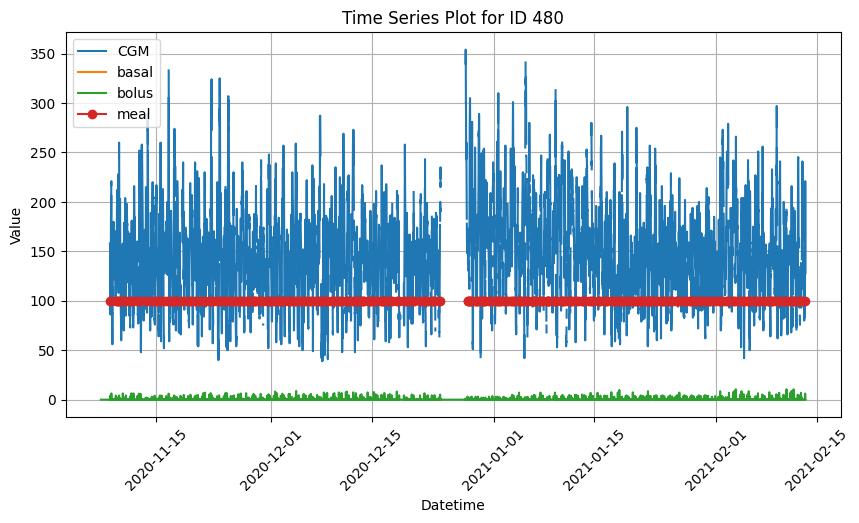

In [68]:
# Plot 
import pandas as pd
import matplotlib.pyplot as plt

subject_id = df_final['id'].unique()[3]

# Filter the data for that ID
df_filtered = df_final[df_final['id'] == subject_id].copy().tail(12*24*100)
df_filtered['meal'] = df_filtered['meal_label'].apply(lambda x: 100 if isinstance(x, str) else x)

# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(df_filtered.index, df_filtered['CGM'], linestyle='-', label=f'CGM')
plt.plot(df_filtered.index, df_filtered['basal'], linestyle='-', label=f'basal')
plt.plot(df_filtered.index, df_filtered['bolus'], linestyle='-', label=f'bolus')
plt.plot(df_filtered.index, df_filtered['meal'], marker='o', linestyle='-', label=f'meal')
plt.xlabel('Datetime')
plt.ylabel('Value')
plt.title(f'Time Series Plot for ID {subject_id}')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
# We see that we now have meals aligned with the rest of the data

In [70]:
df_insulin_type = get_df_from_file(raw_data_file_path, 'IOBP2Insulin.txt', parse_datetime=False, sep='|')
df_insulin_type = df_insulin_type[['PtID', 'InsulinName']]
df_insulin_type = df_insulin_type.rename(columns={'PtID': 'id', 'InsulinName': 'insulin_type'})
df_insulin_type

,id,insulin_type
0,347,Humalog (Lispro)
1,183,Degludec (Tresiba)
2,183,Novolog (Aspart)
3,413,Humalog (Lispro)
4,183,Novolog (Aspart)
...,...,...
1102,474,Humalog (Lispro)
1103,428,Novolog Fiasp
1104,428,Humalog (Lispro)
1105,46,Degludec (Tresiba)


In [71]:
def add_single_value_to_subjects(df, df_new_val, col_name):
    # TODO: this function is very inefficient... add value directly to located rows instead
    processed_dfs = []
    subject_ids = df['id'].unique()
    for subject_id in subject_ids:
        df_subject = df[df['id'] == subject_id].copy()
        df_subject.sort_index(inplace=True)
    
        user_data = df_new_val[df_new_val['id'] == subject_id].copy()
        if not user_data.empty:
            df_subject[col_name] = user_data[col_name].iloc[0]
        else:
            df_subject[col_name] = np.nan        
        processed_dfs.append(df_subject)
        
    df = pd.concat(processed_dfs)
    return df

In [72]:
# Add insulin type
df_final = add_single_value_to_subjects(df_final, df_insulin_type, 'insulin_type')
df_final

,CGM,id,bolus,basal,meal_label,insulin_type
date,,,,,,
2020-08-14 00:00:00,NaN,183,0.0,NaN,NaN,Degludec (Tresiba)
2020-08-14 00:05:00,91.0,183,0.0,NaN,NaN,Degludec (Tresiba)
2020-08-14 00:10:00,102.0,183,0.0,NaN,NaN,Degludec (Tresiba)
2020-08-14 00:15:00,105.0,183,0.0,NaN,NaN,Degludec (Tresiba)
2020-08-14 00:20:00,103.0,183,0.0,NaN,NaN,Degludec (Tresiba)
...,...,...,...,...,...,...
2020-10-16 08:15:00,NaN,195,NaN,NaN,NaN,Humalog (Lispro)
2020-10-16 08:20:00,NaN,195,NaN,NaN,NaN,Humalog (Lispro)
2020-10-16 08:25:00,NaN,195,NaN,NaN,NaN,Humalog (Lispro)


In [74]:
# Add age
df_age = get_df_from_file(raw_data_file_path, 'IOBP2PtRoster.txt', parse_datetime=False, sep='|')
df_age = df_age[['PtID', 'AgeAsofEnrollDt']]
df_age = df_age.rename(columns={'PtID': 'id', 'AgeAsofEnrollDt': 'age'})
df_age

,id,age
0,235,11
1,439,16
2,227,13
3,493,16
4,50,11
...,...,...
435,360,16
436,547,15
437,133,8
438,373,6


In [75]:
# Add age
df_final = add_single_value_to_subjects(df_final, df_age, 'age')
df_final.head()

,CGM,id,bolus,basal,meal_label,insulin_type,age
date,,,,,,,
2020-08-14 00:00:00,NaN,183,0.0,NaN,NaN,Degludec (Tresiba),63
2020-08-14 00:05:00,91.0,183,0.0,NaN,NaN,Degludec (Tresiba),63
2020-08-14 00:10:00,102.0,183,0.0,NaN,NaN,Degludec (Tresiba),63
2020-08-14 00:15:00,105.0,183,0.0,NaN,NaN,Degludec (Tresiba),63
2020-08-14 00:20:00,103.0,183,0.0,NaN,NaN,Degludec (Tresiba),63


In [77]:
# Add gender
df_gender = get_df_from_file(raw_data_file_path, 'IOBP2DiabScreening.txt', parse_datetime=False, sep='|')
df_gender = df_gender[['PtID', 'Sex']]
df_gender = df_gender.rename(columns={'PtID': 'id', 'Sex': 'gender'})
df_gender

,id,gender
0,347,M
1,183,M
2,413,M
3,245,F
4,181,F
...,...,...
435,297,M
436,324,F
437,560,F
438,68,M


In [78]:
# Add weight, height, and gender
df_final = add_single_value_to_subjects(df_final, df_gender, 'gender')
df_final.head()

,CGM,id,bolus,basal,meal_label,insulin_type,age,gender
date,,,,,,,,
2020-08-14 00:00:00,NaN,183,0.0,NaN,NaN,Degludec (Tresiba),63,M
2020-08-14 00:05:00,91.0,183,0.0,NaN,NaN,Degludec (Tresiba),63,M
2020-08-14 00:10:00,102.0,183,0.0,NaN,NaN,Degludec (Tresiba),63,M
2020-08-14 00:15:00,105.0,183,0.0,NaN,NaN,Degludec (Tresiba),63,M
2020-08-14 00:20:00,103.0,183,0.0,NaN,NaN,Degludec (Tresiba),63,M


In [80]:
# Add weight and height
df_weight_height = get_df_from_file(raw_data_file_path, 'IOBP2HeightWeight.txt', parse_datetime=False, sep='|')

print(df_weight_height['HeightUnits'].unique())
print(df_weight_height['WeightUnits'].unique())

# If inches or lbs, --> cm and kg
df_weight_height['Height'] = df_weight_height.apply(
    lambda row: row['Height'] * 2.54 if row['HeightUnits'] != 'cm' else row['Height'],
    axis=1
)
df_weight_height['Weight'] = df_weight_height.apply(
    lambda row: row['Weight'] * 0.453592 if row['WeightUnits'] != 'kg' else row['Weight'],
    axis=1
)
df_weight_height[['Weight', 'Height']] = df_weight_height[['Weight', 'Height']].round(1)
df_weight_height = df_weight_height[['PtID', 'Weight', 'Height']]
df_weight_height = df_weight_height.rename(columns={'PtID': 'id', 'Weight': 'weight', 'Height': 'height'})
df_weight_height

['cm' 'in' nan]
['lbs' 'kg' nan]


,id,weight,height
0,347,115.2,183.4
1,183,93.9,172.7
2,413,68.2,180.3
3,245,82.7,166.4
4,181,54.3,162.6
...,...,...,...
2183,150,61.7,160.0
2184,143,60.0,141.1
2185,68,84.2,188.3
2186,346,57.2,183.6


In [81]:
# Add weight, height, and gender
df_final = add_single_value_to_subjects(df_final, df_weight_height, 'weight')
df_final = add_single_value_to_subjects(df_final, df_weight_height, 'height')
df_final.head()

,CGM,id,bolus,basal,meal_label,insulin_type,age,gender,weight,height
date,,,,,,,,,,
2020-08-14 00:00:00,NaN,183,0.0,NaN,NaN,Degludec (Tresiba),63,M,93.9,172.7
2020-08-14 00:05:00,91.0,183,0.0,NaN,NaN,Degludec (Tresiba),63,M,93.9,172.7
2020-08-14 00:10:00,102.0,183,0.0,NaN,NaN,Degludec (Tresiba),63,M,93.9,172.7
2020-08-14 00:15:00,105.0,183,0.0,NaN,NaN,Degludec (Tresiba),63,M,93.9,172.7
2020-08-14 00:20:00,103.0,183,0.0,NaN,NaN,Degludec (Tresiba),63,M,93.9,172.7


### Save Resampled Data

In [82]:
df_final

,CGM,id,bolus,basal,meal_label,insulin_type,age,gender,weight,height
date,,,,,,,,,,
2020-08-14 00:00:00,NaN,183,0.0,NaN,NaN,Degludec (Tresiba),63,M,93.9,172.7
2020-08-14 00:05:00,91.0,183,0.0,NaN,NaN,Degludec (Tresiba),63,M,93.9,172.7
2020-08-14 00:10:00,102.0,183,0.0,NaN,NaN,Degludec (Tresiba),63,M,93.9,172.7
2020-08-14 00:15:00,105.0,183,0.0,NaN,NaN,Degludec (Tresiba),63,M,93.9,172.7
2020-08-14 00:20:00,103.0,183,0.0,NaN,NaN,Degludec (Tresiba),63,M,93.9,172.7
...,...,...,...,...,...,...,...,...,...,...
2020-10-16 08:15:00,NaN,195,NaN,NaN,NaN,Humalog (Lispro),40,F,102.5,162.7
2020-10-16 08:20:00,NaN,195,NaN,NaN,NaN,Humalog (Lispro),40,F,102.5,162.7
2020-10-16 08:25:00,NaN,195,NaN,NaN,NaN,Humalog (Lispro),40,F,102.5,162.7


In [83]:
save_file_path = "../../data/resampled/"
os.makedirs(save_file_path, exist_ok=True)
df_final.to_csv(save_file_path + 'IOBP2.csv')